# Notebook 1 — Statistical Sensor Validation

**Reviewer concern:** *Insufficient statistical validation — sensor validation lacks RMSE, confidence intervals, and calibration analysis.*

**Reference methodology:** Karimzadeh et al. (*Computers and Electronics in Agriculture*, 2025) use **sensor-independent regression**: predict EC from environmental/operational variables, then quantify agreement with **RMSE, MAE, R²** and confidence bands.

**Important (BitnBolt hardware):** **EC and TDS come from the same probe.** TDS is computed in firmware as $TDS = k \cdot EC + b$. 
They are **not** independent — we never use TDS to predict EC (that would be circular).

**Our validation uses only independent sensors:**
- **EMS:** air temperature, humidity, O₂, pressure (DHT22 + environment)
- **NFADS:** solution temperature (DS18B20), peristaltic pump duty
- **LMS:** BH1750, LDR, TSL2591 (light — when logged)

**Methods:** virtual EC sensor, virtual water-temperature check, EC→TDS formula audit, RMSE/MAE/R², bootstrap 95% CI, calibration + Bland–Altman.

**Outputs:** `results/validation_metrics.csv`, figures in `figures/validation/`


## Step 1 — Setup


In [1]:
# pip install -r requirements.txt
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

try:
    from IPython.display import display
except ImportError:
    display = print

DATA_DIR = Path('.')
FIG_DIR = DATA_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
VAL_DIR = FIG_DIR / 'validation'; VAL_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR/'results').mkdir(exist_ok=True)
def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return dict(RMSE=float(np.sqrt(mean_squared_error(y_true, y_pred))),
                MAE=float(mean_absolute_error(y_true, y_pred)),
                R2=float(r2_score(y_true, y_pred)), n=len(y_true))

def bootstrap_ci(y_true, y_pred, n_boot=500):
    rng = np.random.default_rng(RANDOM_STATE)
    n = len(y_true); rmse_s, mae_s, r2_s = [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        m = regression_metrics(np.asarray(y_true)[idx], np.asarray(y_pred)[idx])
        rmse_s.append(m['RMSE']); mae_s.append(m['MAE']); r2_s.append(m['R2'])
    return {k: np.quantile(v, [0.025, 0.975]) for k, v in
            zip(['RMSE','MAE','R2'], [rmse_s, mae_s, r2_s])}

def cv_metrics_ts(X, y, model, n_splits=5):
    """Time-series CV: return per-fold metrics + mean/std for error bars (like Fig. 8 paper)."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    folds = []
    for tr, te in tscv.split(X):
        m = model.__class__(**model.get_params())
        m.fit(X.iloc[tr], y.iloc[tr])
        pred = m.predict(X.iloc[te])
        folds.append(regression_metrics(y.iloc[te], pred))
    df = pd.DataFrame(folds)
    summary = df.mean().to_dict()
    summary.update({f'{k}_std': df[k].std() for k in ['RMSE','MAE','R2']})
    return df, summary


## Step 2 — Load, merge, and sensor inventory

**Intuition:** Validation must use **physically independent** measurements. 
TDS is excluded from all predictors because it is algebraically tied to EC.


In [2]:
def load_nfads():
    cols = ['ec','tds','ph','waterTemp','createdAt','peristalticPumpA','peristalticPumpB',
            'peristalticPumpPhup','peristalticPumpPhdown']
    chunks = [c for c in pd.read_csv(DATA_DIR/'test.nfads.csv', usecols=cols, chunksize=50_000)]
    df = pd.concat(chunks, ignore_index=True)
    df['createdAt'] = pd.to_datetime(df['createdAt'], utc=True)
    for c in ['ec','tds','ph','waterTemp']: df[c] = pd.to_numeric(df[c], errors='coerce')
    for c in ['peristalticPumpA','peristalticPumpB','peristalticPumpPhup','peristalticPumpPhdown']:
        df[c] = df[c].astype(str).str.lower().eq('true')
    df['pump_any'] = df[['peristalticPumpA','peristalticPumpB','peristalticPumpPhup','peristalticPumpPhdown']].any(axis=1)
    return df.sort_values('createdAt')

def load_ems():
    cols = ['dht22Temp','dht22Moisture','oxygen','pressure','createdAt']
    df = pd.read_csv(DATA_DIR/'test.ems.csv', usecols=cols)
    df['createdAt'] = pd.to_datetime(df['createdAt'], utc=True)
    for c in ['dht22Temp','dht22Moisture','oxygen','pressure']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df.sort_values('createdAt')

def load_lms():
    cols = ['bh1750','ldr','tsl2591','createdAt']
    df = pd.read_csv(DATA_DIR/'test.lms.csv', usecols=cols)
    df['createdAt'] = pd.to_datetime(df['createdAt'], utc=True)
    for c in ['bh1750','ldr','tsl2591']: df[c] = pd.to_numeric(df[c], errors='coerce')
    return df.sort_values('createdAt')

def merge_hourly(nf, ems, lms):
    nf = nf[(nf.ec.between(0,3500)) & (nf.tds.between(0,2500)) & (nf.waterTemp.between(0,45))].copy()
    nf['hour'] = nf.createdAt.dt.floor('h')
    ems_ok = ems[ems.dht22Temp.between(0,60) & ems.dht22Moisture.between(0,100)].copy()
    ems_ok['hour'] = ems_ok.createdAt.dt.floor('h')
    lms['hour'] = lms.createdAt.dt.floor('h')
    h_nf = nf.groupby('hour').agg(
        ec=('ec','median'), tds=('tds','median'),  # tds kept only for formula audit
        waterTemp=('waterTemp','median'),
        pump_duty=('pump_any','mean'),
        pump_phup=('peristalticPumpPhup','mean'),
        pump_nutrient=('peristalticPumpA','mean'),
    ).reset_index()
    h_ems = ems_ok.groupby('hour').agg(
        air_temp=('dht22Temp','median'), humidity=('dht22Moisture','median'),
        oxygen=('oxygen','median'), pressure=('pressure','median'),
    ).reset_index()
    h_lms = lms.groupby('hour').agg(
        light_bh1750=('bh1750','median'), light_ldr=('ldr','median'),
        light_tsl=('tsl2591','median'),
    ).reset_index()
    m = pd.merge(h_nf, h_ems, on='hour', how='inner')
    m = pd.merge(m, h_lms, on='hour', how='left')  # LMS sparse — OK
    for c in ['light_bh1750','light_ldr','light_tsl']:
        m[c] = m[c].fillna(m[c].median())
    return m.sort_values('hour').reset_index(drop=True)

# Independent sensors only (for ML features — never use derived TDS to predict EC)
INDEPENDENT_FEATURES = [
    'air_temp', 'humidity', 'oxygen', 'pressure',
    'waterTemp', 'pump_duty', 'pump_phup', 'pump_nutrient',
    'light_bh1750', 'light_ldr', 'light_tsl',
]

sensor_map = pd.DataFrame([
    ['EC', 'NFADS', 'Conductivity probe', 'Independent', 'Target for virtual sensor'],
    ['TDS', 'NFADS', 'Derived', 'NO — TDS = f(EC) firmware', 'Audit formula only'],
    ['waterTemp', 'NFADS', 'DS18B20', 'Independent', 'Feature + validation target'],
    ['pump_*', 'NFADS', 'Actuators', 'Independent', 'Control inputs'],
    ['air_temp', 'EMS', 'DHT22', 'Independent', 'Feature'],
    ['humidity', 'EMS', 'DHT22', 'Independent', 'Feature'],
    ['oxygen', 'EMS', 'O2 sensor', 'Independent', 'Feature'],
    ['pressure', 'EMS', 'Barometric', 'Independent', 'Feature'],
    ['light_*', 'LMS', 'BH1750/LDR/TSL', 'Independent', 'Feature (when logged)'],
    ['pH', 'NFADS', 'pH probe', 'Independent (when working)', 'Future — currently sparse'],
], columns=['Signal','Subsystem','Hardware','Use in ML','Role'])

nf_raw = load_nfads()
ems_raw = load_ems()
lms_raw = load_lms()
hourly = merge_hourly(nf_raw, ems_raw, lms_raw)
print(f'Hourly merged records: {len(hourly)}')
display(sensor_map)
display(hourly[INDEPENDENT_FEATURES + ['ec','tds']].describe().round(2))


Hourly merged records: 294


,Signal,Subsystem,Hardware,Use in ML,Role
0,EC,NFADS,Conductivity probe,Independent,Target for virtual sensor
1,TDS,NFADS,Derived,NO — TDS = f(EC) firmware,Audit formula only
2,waterTemp,NFADS,DS18B20,Independent,Feature + validation target
3,pump_*,NFADS,Actuators,Independent,Control inputs
4,air_temp,EMS,DHT22,Independent,Feature
5,humidity,EMS,DHT22,Independent,Feature
6,oxygen,EMS,O2 sensor,Independent,Feature
7,pressure,EMS,Barometric,Independent,Feature
8,light_*,LMS,BH1750/LDR/TSL,Independent,Feature (when logged)
9,pH,NFADS,pH probe,Independent (when working),Future — currently sparse


,air_temp,humidity,oxygen,pressure,waterTemp,pump_duty,pump_phup,pump_nutrient,light_bh1750,light_ldr,light_tsl,ec,tds
count,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00
mean,33.81,86.22,1.55,96211.60,28.31,0.32,0.30,0.12,11.03,3.82,9.15,1461.10,730.89
std,4.38,17.27,5.48,18999.57,4.10,0.31,0.29,0.23,184.74,65.49,136.27,466.84,232.25
min,25.35,45.00,0.00,0.00,0.56,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,30.62,71.93,0.00,100112.00,28.25,0.00,0.00,0.00,0.00,0.00,1.00,1186.50,603.34
50%,32.70,99.50,0.00,100287.50,28.97,0.41,0.38,0.00,0.00,0.00,1.00,1487.95,743.00
75%,36.60,100.00,0.00,100468.50,29.50,0.50,0.47,0.16,0.00,0.00,1.00,1922.75,960.08
max,45.70,100.00,23.99,100926.00,36.44,1.00,1.00,1.00,3167.00,1123.00,2337.00,2500.00,1250.00


## Step 2b — Pearson correlation (independent sensors only)

**Intuition (paper §3.4.2):** Correlation matrix shows which environmental drivers co-vary with EC — motivates feature selection.


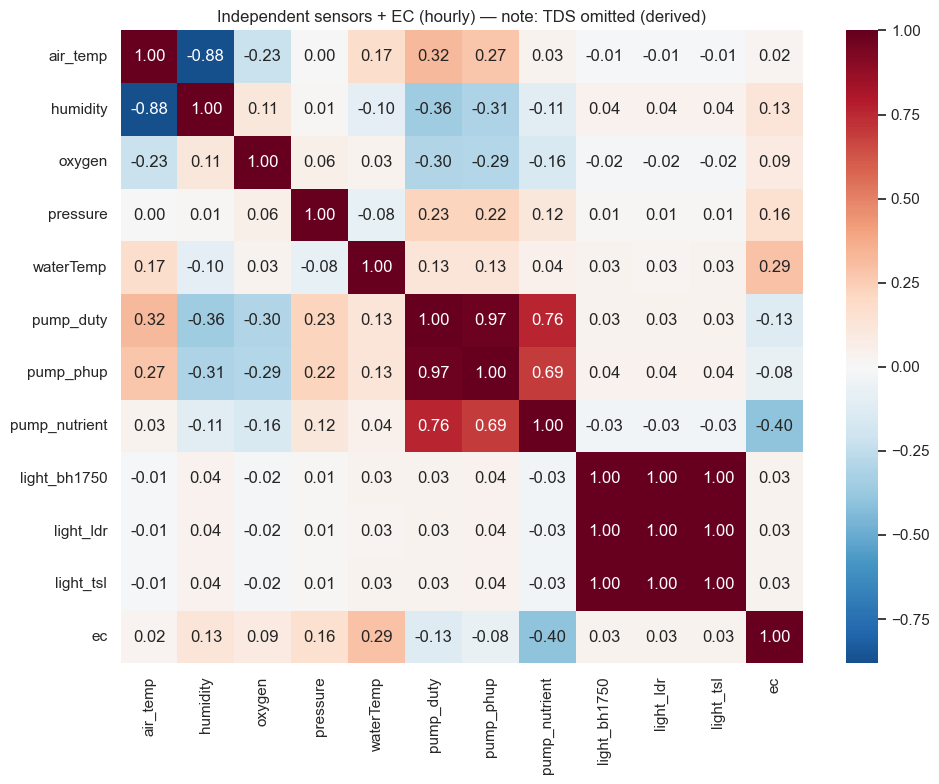

Top |r| with EC:
pump_nutrient    0.398
waterTemp        0.289
pressure         0.158
pump_duty        0.130
humidity         0.127
oxygen           0.091
Name: ec, dtype: float64


In [3]:
indep = hourly[INDEPENDENT_FEATURES + ['ec']]
corr = indep.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Independent sensors + EC (hourly) — note: TDS omitted (derived)')
plt.tight_layout(); plt.savefig(VAL_DIR/'fig_independent_corr.png', dpi=150, bbox_inches='tight'); plt.show()
print('Top |r| with EC:')
print(corr['ec'].drop('ec').abs().sort_values(ascending=False).head(6).round(3))


## Step 3 — Virtual EC sensor (independent features only)

**Intuition:** Predict EC from climate + solution temperature + pumps + light — **never from TDS**. 
Large residuals $|EC_{obs} - EC_{pred}|$ flag drift/bias/faults (Karimzadeh et al., sensor-independent FDD).

Models: **Ridge**, **SVR**, **ANN** with time-series CV.


In [4]:
FEATURES = [c for c in INDEPENDENT_FEATURES if c in hourly.columns]
TARGET = 'ec'
X = hourly[FEATURES]; y = hourly[TARGET]

models = {
    'Ridge': Ridge(alpha=1.0),
    'SVR': SVR(C=100, gamma='scale'),
    'ANN': MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500, random_state=RANDOM_STATE),
}

val_rows = []
pred_store = {}
tscv = TimeSeriesSplit(n_splits=5)
for name, model in models.items():
    fold_df, summary = cv_metrics_ts(X, y, model)
    pred_full = np.full(len(y), np.nan)
    for tr, te in tscv.split(X):
        m = model.__class__(**model.get_params())
        m.fit(X.iloc[tr], y.iloc[tr])
        pred_full[te] = m.predict(X.iloc[te])
    ok = ~np.isnan(pred_full)
    ci = bootstrap_ci(y[ok], pred_full[ok])
    row = {'model': name, **summary,
           'RMSE_CI_lo': ci['RMSE'][0], 'RMSE_CI_hi': ci['RMSE'][1],
           'MAE_CI_lo': ci['MAE'][0], 'MAE_CI_hi': ci['MAE'][1]}
    val_rows.append(row)
    pred_store[name] = pred_full
    print(f"{name}: RMSE={summary['RMSE']:.2f} +/- {summary['RMSE_std']:.2f}, R2={summary['R2']:.4f}")

val_df = pd.DataFrame(val_rows)
display(val_df.round(4))


Ridge: RMSE=466.00 +/- 165.19, R2=-0.7208
SVR: RMSE=479.63 +/- 126.35, R2=-0.5608
ANN: RMSE=2660.03 +/- 687.67, R2=-61.4290


,model,RMSE,MAE,R2,n,RMSE_std,MAE_std,R2_std,RMSE_CI_lo,RMSE_CI_hi,MAE_CI_lo,MAE_CI_hi
0,Ridge,465.9965,380.0557,-0.7208,49.0,165.1946,156.9537,1.1659,444.8868,528.9124,341.6039,415.1411
1,SVR,479.6261,392.9085,-0.5608,49.0,126.3523,153.2177,0.3443,450.5140,533.3997,357.3637,431.7671
2,ANN,2660.0324,2614.7019,-61.4290,49.0,687.6662,730.8392,39.5693,2641.0734,2810.8380,2513.4989,2705.6718


## Step 4 — Cross-validation error bars (replicates paper Fig. 8c)

**Intuition:** A single RMSE is insufficient. Error bars show **stability across time folds**.


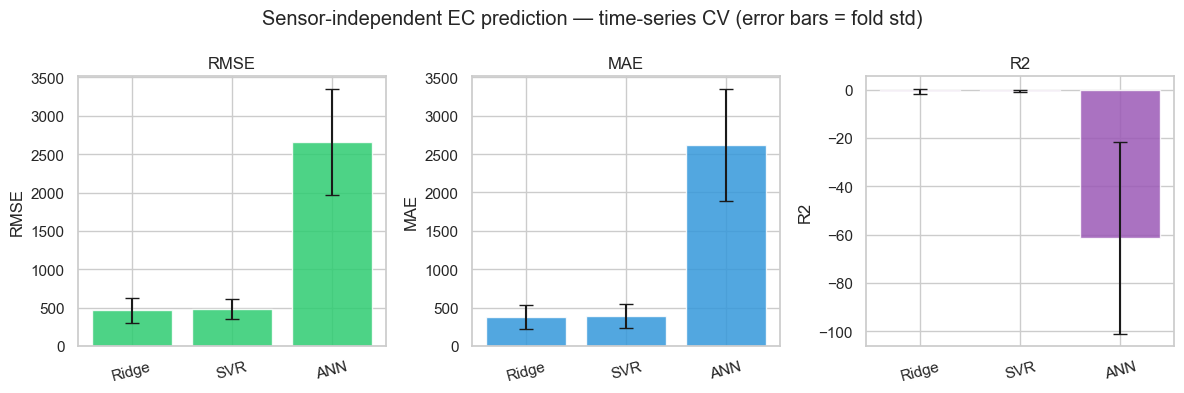

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = ['RMSE', 'MAE', 'R2']
colors = ['#2ecc71', '#3498db', '#9b59b6']
x = np.arange(len(val_df))
for ax, met, c in zip(axes, metrics, colors):
    means = val_df[met].values
    stds = val_df[f'{met}_std'].values
    ax.bar(x, means, yerr=stds, capsize=5, color=c, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(val_df['model'], rotation=15)
    ax.set_title(met); ax.set_ylabel(met)
plt.suptitle('Sensor-independent EC prediction — time-series CV (error bars = fold std)')
plt.tight_layout()
plt.savefig(VAL_DIR/'fig_cv_errorbars.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 5 — Calibration analysis (observed vs predicted)

**Intuition:** Ideal calibration: predicted = observed (slope=1, intercept=0). 
**Bland–Altman** plots reveal systematic bias vs magnitude.


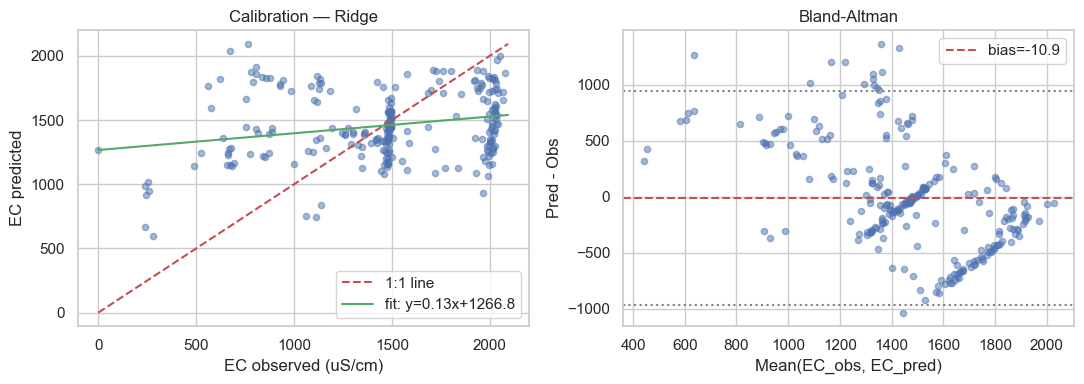

Best model (Ridge): RMSE=488.86 [444.89, 528.91]
  MAE=380.06, R2=-0.0463


In [6]:
best_name = val_df.loc[val_df['RMSE'].idxmin(), 'model']
y_pred = pred_store[best_name]
ok = ~np.isnan(y_pred)
y_pred = y_pred[ok]; y_true = y.values[ok]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
axes[0].scatter(y_true, y_pred, alpha=0.5, s=20)
axes[0].plot([mn,mx],[mn,mx],'r--',label='1:1 line')
slope, intercept, r, _, _ = stats.linregress(y_true, y_pred)
axes[0].plot([mn,mx], slope*np.array([mn,mx])+intercept, 'g-', label=f'fit: y={slope:.2f}x+{intercept:.1f}')
axes[0].set(xlabel='EC observed (uS/cm)', ylabel='EC predicted', title=f'Calibration — {best_name}')
axes[0].legend()
diff = y_pred - y_true; mean = (y_pred + y_true)/2
axes[1].scatter(mean, diff, alpha=0.5, s=20)
axes[1].axhline(diff.mean(), color='r', ls='--', label=f'bias={diff.mean():.1f}')
lo, hi = diff.mean()-1.96*diff.std(), diff.mean()+1.96*diff.std()
axes[1].axhline(lo, color='gray', ls=':'); axes[1].axhline(hi, color='gray', ls=':')
axes[1].set(xlabel='Mean(EC_obs, EC_pred)', ylabel='Pred - Obs', title='Bland-Altman')
axes[1].legend()
plt.tight_layout()
plt.savefig(VAL_DIR/'fig_calibration_bland_altman.png', dpi=150, bbox_inches='tight')
plt.show()

m_final = regression_metrics(y_true, y_pred)
ci_final = bootstrap_ci(y_true, y_pred)
print(f'Best model ({best_name}): RMSE={m_final["RMSE"]:.2f} [{ci_final["RMSE"][0]:.2f}, {ci_final["RMSE"][1]:.2f}]')
print(f'  MAE={m_final["MAE"]:.2f}, R2={m_final["R2"]:.4f}')


## Step 6 — EC→TDS formula audit (same probe — NOT independent validation)

**Intuition:** Firmware computes $TDS = k \cdot EC + b$. We fit $(k,b)$ on data to check **implementation consistency** 
(max residual, RMSE). High R² here is **expected** — do not cite this as cross-sensor validation in the paper.


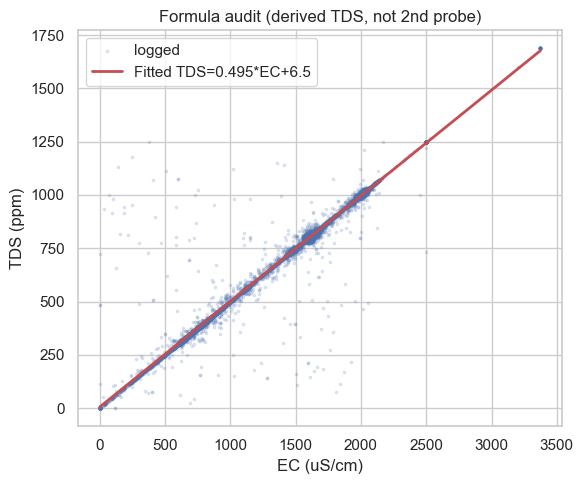

{'k_fitted': 0.49498104482218697, 'b_fitted': 6.478858894495261, 'pearson_r': 0.9901179863691913, 'max_abs_residual_ppm': 1059.2077341738297, 'rmse_formula_ppm': 36.753295158657146, 'note': 'Same sensor — formula check only'}


In [7]:
sub = nf_raw[nf_raw.ec.between(0,3500) & nf_raw.tds.between(0,2500)].sample(
    n=min(25000, len(nf_raw)), random_state=RANDOM_STATE)
k, b, r, _, _ = stats.linregress(sub.ec, sub.tds)
tds_from_ec = k * sub.ec + b
resid_formula = sub.tds - tds_from_ec
formula_audit = {
    'k_fitted': k, 'b_fitted': b, 'pearson_r': r,
    'max_abs_residual_ppm': float(resid_formula.abs().max()),
    'rmse_formula_ppm': float(np.sqrt((resid_formula**2).mean())),
    'note': 'Same sensor — formula check only',
}
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(sub.ec, sub.tds, s=3, alpha=0.15, label='logged')
xx = np.linspace(sub.ec.min(), sub.ec.max(), 100)
ax.plot(xx, k*xx+b, 'r-', lw=2, label=f'Fitted TDS={k:.3f}*EC+{b:.1f}')
ax.set(xlabel='EC (uS/cm)', ylabel='TDS (ppm)', title='Formula audit (derived TDS, not 2nd probe)')
ax.legend(); plt.tight_layout()
plt.savefig(VAL_DIR/'fig_ec_tds_formula_audit.png', dpi=150, bbox_inches='tight'); plt.show()
print(formula_audit)


## Step 6b — Virtual water temperature (cross-subsystem validation)

**Intuition:** `waterTemp` (DS18B20 in solution) should relate to `air_temp` and `humidity` (EMS) but is a **separate sensor** — valid second validation target.


Virtual waterTemp: RMSE=4.73 C [3.34,5.99], R2=-0.126


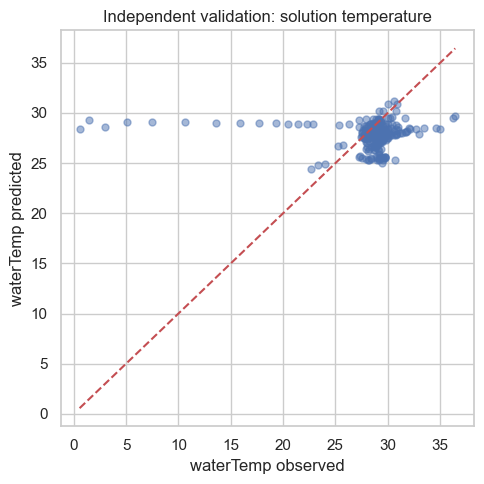

In [8]:
WT_FEATURES = ['air_temp','humidity','pressure','pump_duty','light_bh1750']
X_wt = hourly[WT_FEATURES]; y_wt = hourly['waterTemp']
pred_wt = np.full(len(y_wt), np.nan)
for tr, te in TimeSeriesSplit(5).split(X_wt):
    m = Ridge(1.0); m.fit(X_wt.iloc[tr], y_wt.iloc[tr]); pred_wt[te] = m.predict(X_wt.iloc[te])
ok_wt = ~np.isnan(pred_wt)
m_wt = regression_metrics(y_wt[ok_wt], pred_wt[ok_wt])
ci_wt = bootstrap_ci(y_wt[ok_wt], pred_wt[ok_wt])
print(f'Virtual waterTemp: RMSE={m_wt["RMSE"]:.2f} C [{ci_wt["RMSE"][0]:.2f},{ci_wt["RMSE"][1]:.2f}], R2={m_wt["R2"]:.3f}')
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_wt[ok_wt], pred_wt[ok_wt], alpha=0.5, s=25)
mn, mx = y_wt[ok_wt].min(), y_wt[ok_wt].max()
ax.plot([mn,mx],[mn,mx],'r--'); ax.set(xlabel='waterTemp observed', ylabel='waterTemp predicted')
ax.set_title('Independent validation: solution temperature'); plt.tight_layout()
plt.savefig(VAL_DIR/'fig_water_temp_validation.png', dpi=150, bbox_inches='tight'); plt.show()


## Step 7 — Residual-based validation band (±3% rule, paper Eq. 11 spirit)

**Intuition:** Paper flags faults when predictions fall outside sensor accuracy (±3%). 
We compute **in-tolerance rate** = fraction of hours where relative error < 3%.


Hours within +/-3.0% of virtual sensor: 9.4%


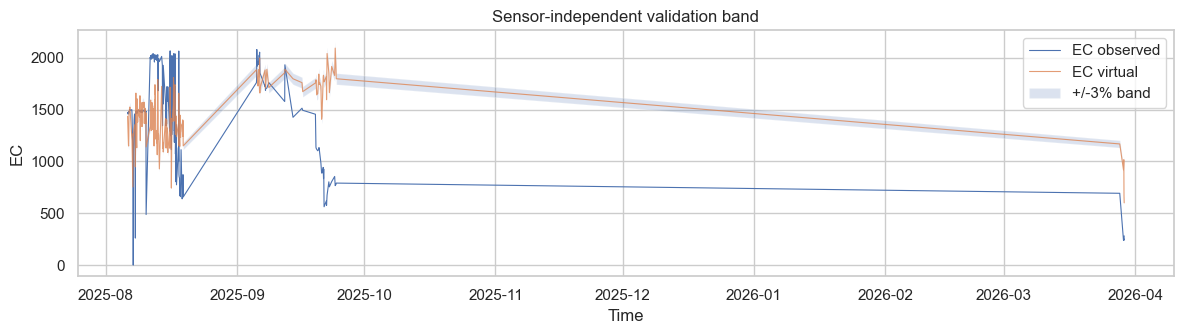

In [9]:
rel_err = np.abs(y_pred - y_true) / np.maximum(np.abs(y_true), 1) * 100
TOL = 3.0  # percent
in_tol = (rel_err <= TOL).mean() * 100
print(f'Hours within +/-{TOL}% of virtual sensor: {in_tol:.1f}%')

hourly_plot = hourly.iloc[ok].copy().reset_index(drop=True)
hourly_plot['ec_pred'] = y_pred
hourly_plot['residual'] = hourly_plot['ec'] - hourly_plot['ec_pred']
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(hourly_plot['hour'], hourly_plot['ec'], label='EC observed', lw=0.8)
ax.plot(hourly_plot['hour'], hourly_plot['ec_pred'], label='EC virtual', lw=0.8, alpha=0.8)
ax.fill_between(hourly_plot['hour'], hourly_plot['ec_pred']*0.97, hourly_plot['ec_pred']*1.03,
                alpha=0.2, label='+/-3% band')
ax.set(xlabel='Time', ylabel='EC'); ax.legend(); ax.set_title('Sensor-independent validation band')
plt.tight_layout(); plt.savefig(VAL_DIR/'fig_validation_band.png', dpi=150, bbox_inches='tight'); plt.show()


## Step 8 — Distribution analysis (violin plots, paper Fig. 4 style)

Compare **normal** residuals vs **anomaly** (large |residual|) to show statistical separation.


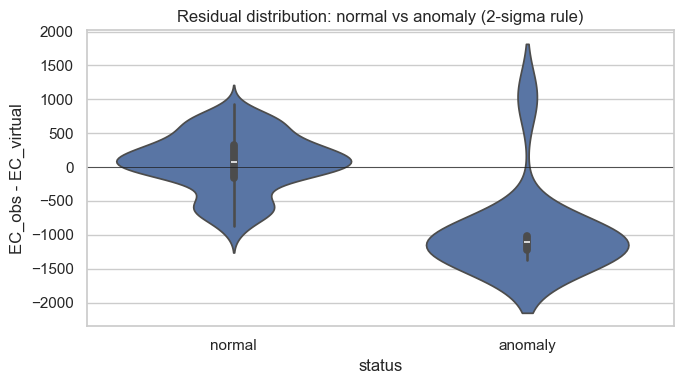

normal: mean=61.3, std=424.9, n=233
anomaly: mean=-968.0, std=643.3, n=12


In [10]:
hourly_plot['status'] = np.where(np.abs(hourly_plot['residual']) > hourly_plot['residual'].std()*2,
                                 'anomaly', 'normal')
fig, ax = plt.subplots(figsize=(7, 4))
sns.violinplot(data=hourly_plot, x='status', y='residual', ax=ax, inner='box')
ax.axhline(0, color='k', lw=0.5)
ax.set(title='Residual distribution: normal vs anomaly (2-sigma rule)', ylabel='EC_obs - EC_virtual')
plt.tight_layout(); plt.savefig(VAL_DIR/'fig_violin_residuals.png', dpi=150, bbox_inches='tight'); plt.show()

for s in ['normal','anomaly']:
    r = hourly_plot.loc[hourly_plot.status==s, 'residual']
    print(f'{s}: mean={r.mean():.1f}, std={r.std():.1f}, n={len(r)}')


## Step 9 — Export validation table for manuscript

**Copy Table:** Include RMSE (95% CI), MAE, R², in-tolerance %, calibration k.


In [11]:
val_df['in_tolerance_pct_3'] = in_tol
val_df['features'] = ', '.join(FEATURES)
val_df.to_csv(DATA_DIR/'results'/'validation_metrics.csv', index=False)
pd.DataFrame([formula_audit]).to_csv(DATA_DIR/'results'/'ec_tds_formula_audit.csv', index=False)
pd.DataFrame([{**m_wt, 'target': 'waterTemp', **{f'RMSE_CI_{i}': ci_wt['RMSE'][j] for j,i in enumerate(['lo','hi'])}}]).to_csv(
    DATA_DIR/'results'/'water_temp_validation.csv', index=False)
print('Saved results/*.csv')

print('\n--- Suggested manuscript paragraph ---')
print(f'EC was validated using a sensor-independent virtual model ({best_name}) built from '
      f'EMS climate, solution temperature, actuators, and LMS light — excluding derived TDS. '
      f'RMSE = {m_final["RMSE"]:.1f} uS/cm (95% CI: {ci_final["RMSE"][0]:.1f}-{ci_final["RMSE"][1]:.1f}), '
      f'R2 = {m_final["R2"]:.3f}; {in_tol:.1f}% within +/-3%. '
      f'Separately, water temperature was predicted from independent EMS features (RMSE = {m_wt["RMSE"]:.2f} C). '
      f'TDS tracks EC via firmware conversion (k={k:.3f}); max formula residual = {formula_audit["max_abs_residual_ppm"]:.1f} ppm.')


Saved results/*.csv

--- Suggested manuscript paragraph ---
EC was validated using a sensor-independent virtual model (Ridge) built from EMS climate, solution temperature, actuators, and LMS light — excluding derived TDS. RMSE = 488.9 uS/cm (95% CI: 444.9-528.9), R2 = -0.046; 9.4% within +/-3%. Separately, water temperature was predicted from independent EMS features (RMSE = 4.73 C). TDS tracks EC via firmware conversion (k=0.495); max formula residual = 1059.2 ppm.
